In [78]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Telco Costumer Churn Preditions

## Overview

Customer churn occurs when a costumer has left the company. For a telecom company it is crucial to predict who is likely to leave (churn) given that it is more expensive to acquire new costumers than to keep existing ones.

## The Goal

We will explore and analyze Teleco costumer data to predict what customers are likely to leave.

In [79]:
# Load libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Loading and Inspecting the Data

We will inspect the data and fix any error in the raw data.

In [80]:
# Load dataset
df = pd.read_csv(
    '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    # nrows=2000
)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [81]:
print(df.describe())
print(df.isna().sum())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [82]:
# Transform 'TotalCharges' to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Finding NaNs
print(f"Total NaNs: {df['TotalCharges'].isnull().sum()}")

# Removing NaN
df = df.dropna(subset='TotalCharges')

df.isna().sum()

Total NaNs: 11


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [83]:
# Find uniques
df.nunique()

customerID          7032
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [84]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## EDA and Visualization

What I want to do here is to explore the variables in the table to find the most relevant features that may influence `Churn`

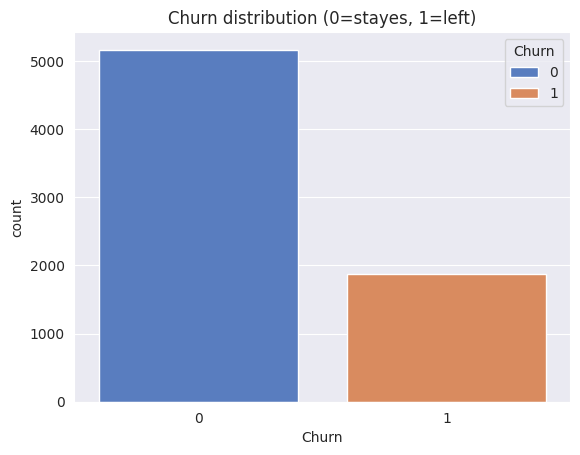

In [85]:
# Set plotting style
sns.set_style('darkgrid')
sns.set_palette('muted')

# Visualize churn distribution
sns.countplot(data=df, x='Churn', hue='Churn')
plt.title('Churn distribution (0=stayes, 1=left)')
plt.show()

We can appreciate that customers stay (0) almost 3x than the numer of customers that left (1)

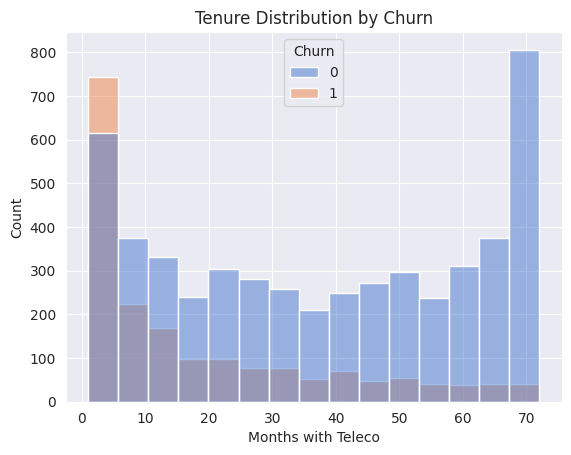

In [86]:
sns.histplot(x='tenure', hue='Churn', data=df)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Months with Teleco')
plt.show()

In [87]:
df.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

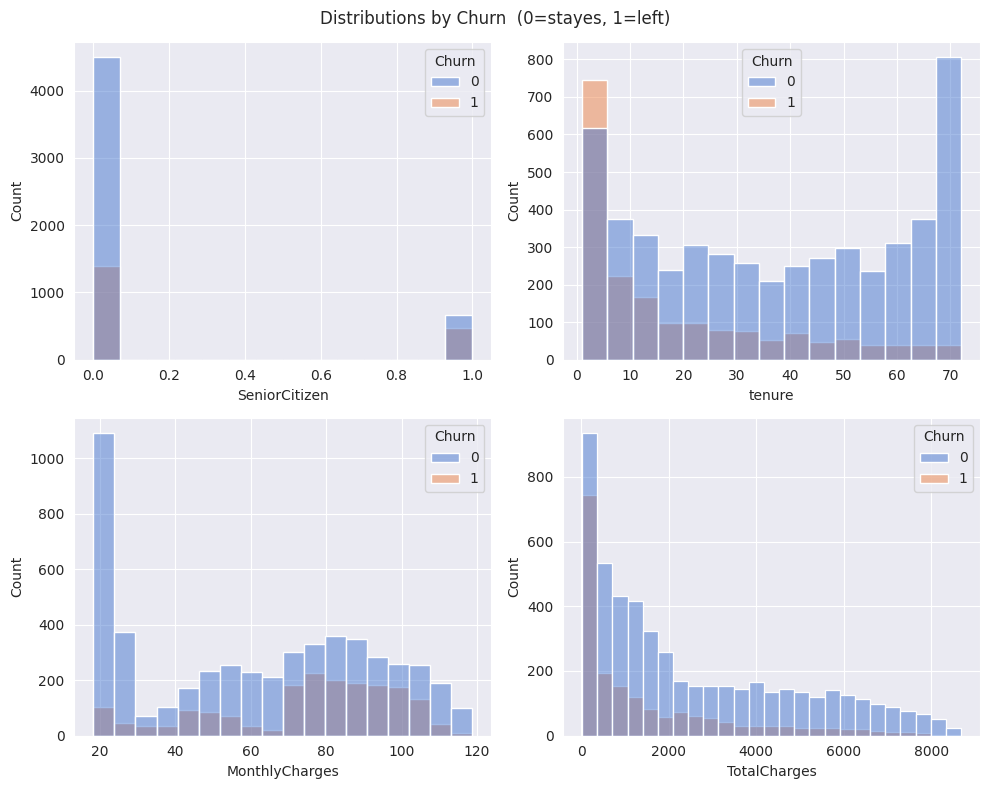

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

i = 0
df_num_cols = df.select_dtypes(include="number").columns
for ax in axes:
    # First column
    sns.histplot(data=df, x=df_num_cols[i], hue='Churn', ax=ax[0])
    i +=1
    # Second column
    sns.histplot(data=df, x=df_num_cols[i], hue='Churn', ax=ax[1])
    i += 1

fig.suptitle('Distributions by Churn  (0=stayes, 1=left)')
plt.tight_layout()

Let us explore the distribution of the other features by churn.

**Senior Citizen**

We can see in this plot that the majority of customers in Telecon are non-senior, and that it is the younger customers that stay with Telecon.

**Tenure**

The customers that have been with the company the longest seem to the the least likely to leave. In other words: long-time customers are the most loyal to Teleco.

**Monthly Charges**

The costumers that stay with Telecon are the ones that receive < 20 charges per month. The likelelyhood that customers leave Telecon grows if they receive > 60 charges per month.

**Total Charges**

This quantity at first sight doesn't throw any trend that may inform us if this causes customers to leave Telecon.

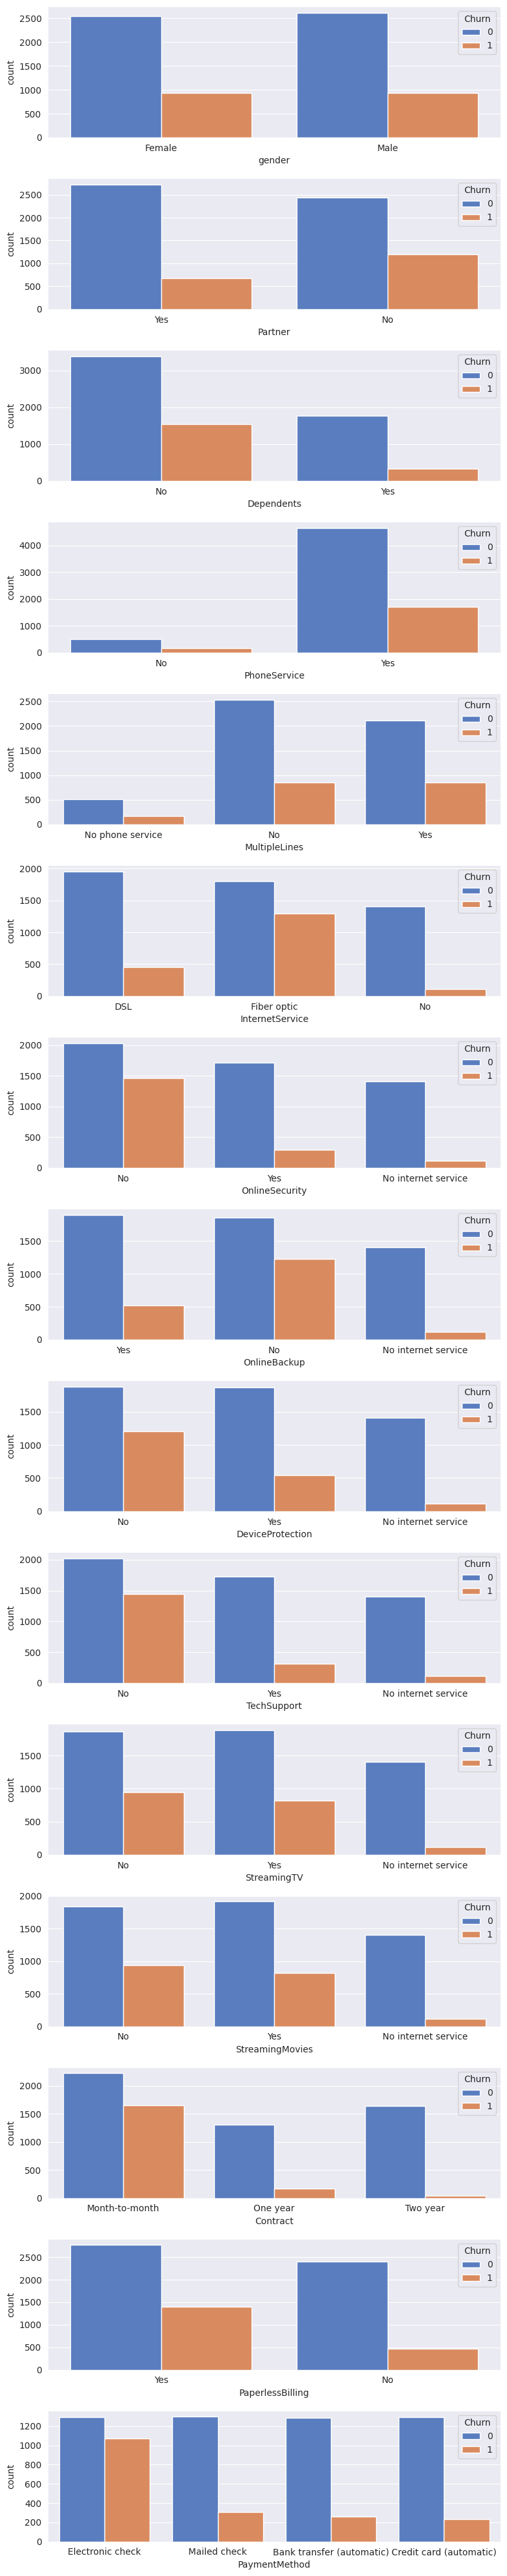

In [89]:
df_obj_cols = df.select_dtypes(include="object").columns[1:]
obj_cols_len = len(df_obj_cols)

fig, axes = plt.subplots(obj_cols_len, figsize=(8, 40))

for ax, col in zip(axes, df_obj_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)

plt.tight_layout()

_Note_: I will describe the most relevant plots from the above analysis.

**Online Backup**

There seems to be a rise in customers leaving Telecon if they do not have online backup.

**Device Protection**

The population of churns that have no device protection. If customers have device protection, tend to not leave Telecon.

**Tech Support**

Customers without tech support tend to leave the company as opposed to those with technical support, or no internet service

**Contract**

Te distribution of Mont-to-Month show that show that in this group the population of customers that leave Telecon is higher.

**Payment Method**

In this class, the group of customers that pay through electronic check show that the population of that leave Telecon is higher.

## Preprocessing

Here we will prepare the data for our Machine Learning model(s). This means converting `object` columns into numbers, and scaling our numerical features.

In [116]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [117]:
# Removing customerID
df_clean = df.drop(columns=['customerID'])

# One-hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=df_obj_cols, drop_first=True)

# Define variables and split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

We will train several models 

In [119]:
models = {
    'Logistic Regression': LogisticRegression(),
    'K-nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=123),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=123),
    'SVM': SVC(kernel='rbf', probability=True, random_state=123),
    'Gradient Boost': GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        loss='log_loss',
        random_state=123
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=123
    )
}

# Re-defining dictionary with Pipelines
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ('scaler', StandardScaler()),  # Step 1: Scale the data
        ('classifier', model)         # Step 2: Run the model
    ])

model_scores = {}

print('Initiating Model Training')

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    
    # 1. Fit the pipeline (Scales data + Trains model)
    pipe.fit(X_train, y_train)
    
    # 2. Get predictions
    y_pred = pipe.predict(X_test)
    y_probs = pipe.predict_proba(X_test)[:, 1] # Needed for ROC AUC
    
    # 3. Calculate all metrics
    model_scores[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'roc_curve': roc_curve(y_test, y_probs),
        'roc_auc': roc_auc_score(y_test, y_probs)
    }

# 4. Convert to the DataFrame format we discussed earlier
results_df = pd.DataFrame.from_dict(model_scores, orient='index').reset_index()
results_df.rename(columns={'index': 'model'}, inplace=True)

# 5. Display the numeric summary (sorted by F1)
summary_cols = ['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
print("\n-> Evaluation Complete!")
print(results_df[summary_cols].sort_values(by='f1_score', ascending=False))

Initiating Model Training
Training Logistic Regression...
Training K-nearest Neighbors...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training Gradient Boost...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:40:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Evaluation Complete!
                 model  accuracy  precision    recall  f1_score   roc_auc
0  Logistic Regression  0.810235   0.738411  0.542579  0.625526  0.860704
5       Gradient Boost  0.803127   0.726351  0.523114  0.608204  0.858116
6              XGBoost  0.802416   0.726962  0.518248  0.605114  0.859143
4                  SVM  0.798863   0.731884  0.491484  0.588064  0.802358
3        Random Forest  0.796020   0.729630  0.479319  0.578561  0.830144
2        Decision Tree  0.781805   0.678082  0.481752  0.563300  0.834347
1  K-nearest Neighbors  0.746979   0.579251  0.489051  0.530343  0.767883


This belongs to an older version:

```python
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    model_scores[name] = {}
    print(f'-> {name} performance:')
    score = accuracy_score(y_test, y_pred)
    model_scores[name]['accuracy'] = score
    print(f'    Accuracy: {score:.4f}')
    score = precision_score(y_test, y_pred)
    model_scores[name]['precision'] = score
    print(f'    Precision: {score:.4f}')
    score = recall_score(y_test, y_pred)
    model_scores[name]['recall'] = score
    print(f'    Recall: {score:.4f}')
    score = f1_score(y_test, y_pred)
    model_scores[name]['f1_score'] = score
    print(f'    F1 Score: {score:.4f}')
    score = confusion_matrix(y_test, y_pred)
    model_scores[name]['confusion_matrix'] = score
    score = roc_curve(y_test, y_pred)
    model_scores[name]['roc_curve'] = score
    score = roc_auc_score(y_test, y_pred)
    model_scores[name]['roc_auc'] = score
    print(f'    ROC-AUC: {score:.4f}')

print('\n=== All models trained successfully ===')
```

## Evaluation & Conclusion

Now that we have the performance of each model, let us compare and contrast to pick the best model for our data.

In [113]:
results_df = pd.DataFrame.from_dict(
    model_scores,
    orient='index',
    columns=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
).reset_index()
results_df.rename(columns={'index': 'model'}, inplace=True)

results_df.head(10)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.810235,0.738411,0.542579,0.625526,0.731631
1,K-nearest Neighbors,0.746979,0.579251,0.489051,0.530343,0.671232
2,Decision Tree,0.781805,0.678082,0.481752,0.563300,0.693687
3,Random Forest,0.796020,0.729630,0.479319,0.578561,0.703013
4,SVM,0.798863,0.731884,0.491484,0.588064,0.708593
5,Gradient Boost,0.803127,0.726351,0.523114,0.608204,0.720895
6,XGBoost,0.802416,0.726962,0.518248,0.605114,0.718963


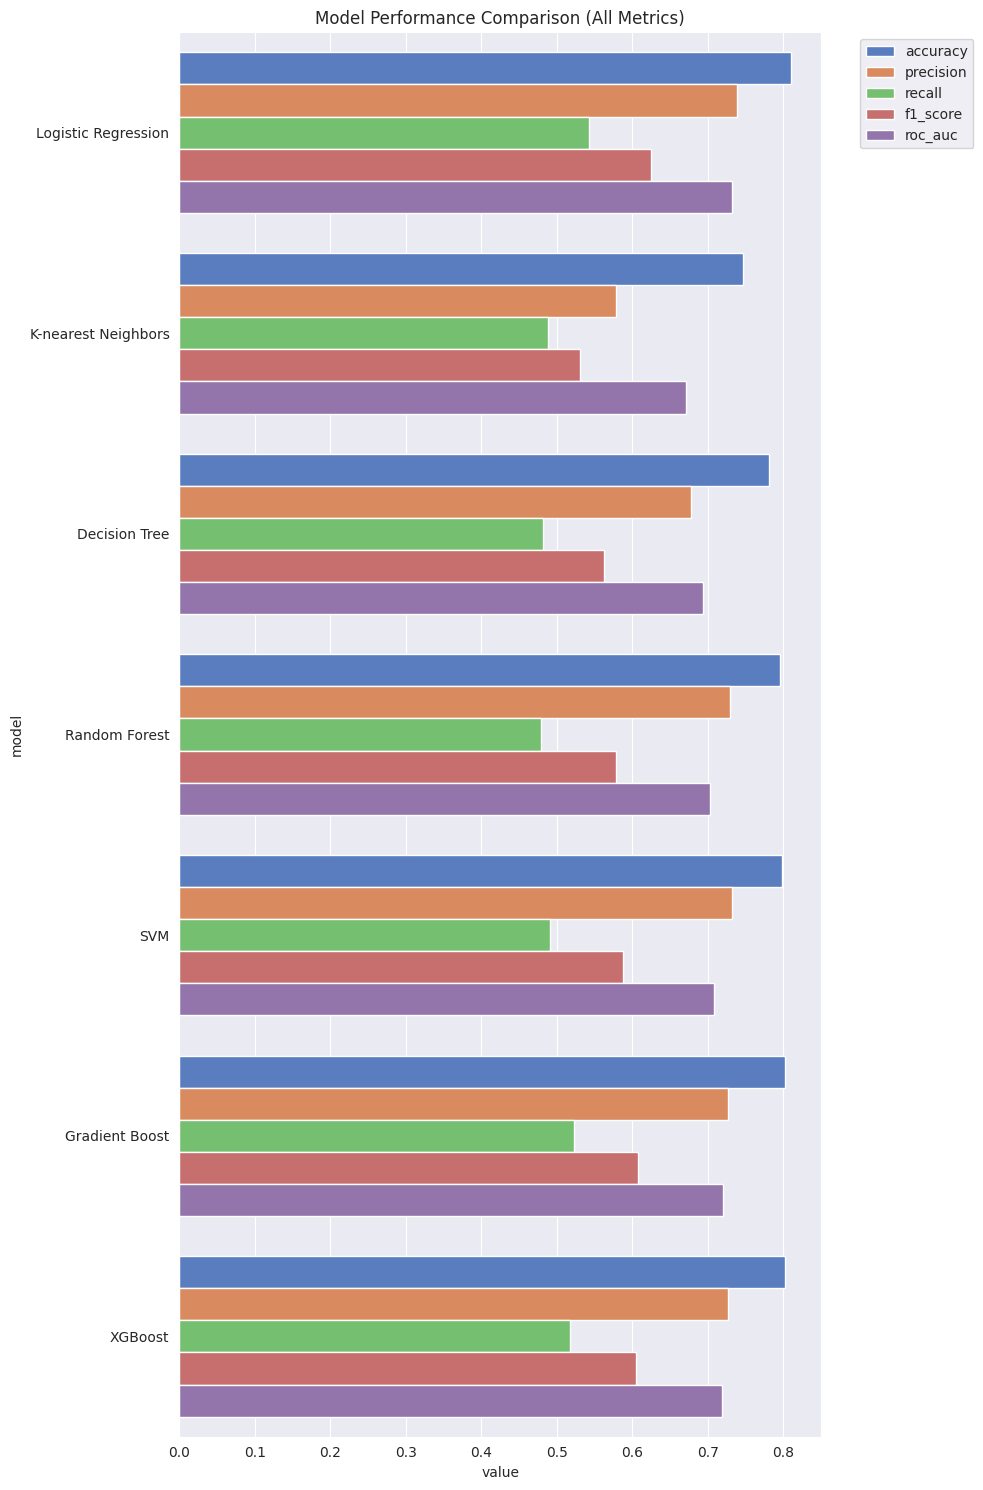

In [114]:
# Transforming dataframe from wide to long
melt_df = results_df.melt(id_vars='model', var_name='metric', value_name='value')

# Plotting scores per model
plt.figure(figsize=(10, 15))
sns.barplot(x='value', y='model', hue='metric', data=melt_df)

plt.title('Model Performance Comparison (All Metrics)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()